# Retinal Fundus Classification — Kaggle Version

In [1]:
# ============================================================
# CELL 1 — Install dependencies
# (torch, torchvision, opencv already pre-installed on Kaggle)
# ============================================================
!pip install -q timm albumentations --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.6 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Preprocessed data is already here — no need to run CLAHE again
PROC = "/kaggle/input/datasets/shubhamprakash11/processed-dataset2/content/data_proc"

print("\nVerifying structure:")
for size in ["224", "384"]:
    for split in ["train", "val", "test"]:
        p = os.path.join(PROC, size, split)
        if os.path.exists(p):
            total = sum(
                len(os.listdir(os.path.join(p, c)))
                for c in os.listdir(p)
                if os.path.isdir(os.path.join(p, c))
            )
            print(f"  {size}/{split}: {total} images")
        else:
            print(f"  {size}/{split}: NOT FOUND")

CUDA: True
GPU: Tesla T4

Verifying structure:
  224/train: 22400 images
  224/val: 2800 images
  224/test: 2800 images
  384/train: 22400 images
  384/val: 2800 images
  384/test: 2800 images


In [3]:
import os

# Direct path — confirmed from os.walk output earlier
DATA_ROOT = "/kaggle/input/datasets/shubhamprakash11/processed-dataset2/content/data_proc"

# Verify it exists
print("Data root exists:", os.path.exists(DATA_ROOT))
print("\nContents:")
for item in sorted(os.listdir(DATA_ROOT)):
    print(" ", item)


Data root exists: True

Contents:
  224
  384


In [4]:
# Preprocessed data already exists — skip CLAHE/resize
# Just point directly to the mounted dataset

PROC      = "/kaggle/input/datasets/shubhamprakash11/processed-dataset2/content/data_proc"
TRAIN_224 = f"{PROC}/224/train"
VAL_224   = f"{PROC}/224/val"
TEST_224  = f"{PROC}/224/test"
TRAIN_380 = f"{PROC}/384/train"
VAL_380   = f"{PROC}/384/val"

SAVE_DIR  = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Paths set. No preprocessing needed — using existing data_proc.")

Paths set. No preprocessing needed — using existing data_proc.


In [5]:
# ============================================================
# CELL 5 — Imports + config
# ============================================================
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report
from scipy.optimize import minimize
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark     = True
torch.backends.cudnn.deterministic = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Paths (Kaggle) ----
PROC        = DATA_ROOT
TRAIN_224   = f"{PROC}/224/train"
VAL_224     = f"{PROC}/224/val"
TEST_224    = f"{PROC}/224/test"
TRAIN_384   = f"{PROC}/384/train"
VAL_384     = f"{PROC}/384/val"
TEST_384    = f"{PROC}/384/test"

# Models saved to /kaggle/working — download from Output tab after run
SAVE_DIR    = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Hyperparameters ----
EPOCHS      = 20
LR          = 2e-4
BATCH_224   = 64
BATCH_384   = 24
WARMUP_EP   = 3
GAMMA_FOCAL = 2.0
WORKERS     = 2    # Kaggle max recommended

print("Config ready.")

Device: cuda
Config ready.


In [6]:
# ============================================================
# CELL 6 — Augmentation pipelines
# Fixed: CoarseDropout new API, Affine instead of ShiftScaleRotate
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
MINORITY      = {'Pathological_Myopia', 'Cataract', 'Hypertensive_Retinopathy'}

def build_train_transform(size, minority=False):
    base = [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent=0.05,
            scale=(0.9, 1.1),
            rotate=(-20, 20),
            p=0.5
        ),
        A.OneOf([
            A.GridDistortion(p=1.0),
            A.ElasticTransform(p=1.0),
            A.OpticalDistortion(p=1.0),
        ], p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.1, hue=0.05, p=0.5),
        A.GaussNoise(p=0.2),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    ]
    if minority:
        base += [
            A.RandomBrightnessContrast(
                brightness_limit=0.3, contrast_limit=0.3, p=0.5),
            A.CLAHE(clip_limit=4.0, p=0.3),
            A.CoarseDropout(
                num_holes_range=(1, 8),
                hole_height_range=(1, size // 16),
                hole_width_range=(1, size // 16),
                p=0.3
            ),
        ]
    base += [
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
    return A.Compose(base)

def build_val_transform():
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


class FundusDataset(datasets.ImageFolder):
    def __init__(self, root, size, train=True):
        super().__init__(root)
        self.size  = size
        self.train = train

    def __getitem__(self, index):
        path, label = self.samples[index]
        img = np.array(Image.open(path).convert("RGB"))
        if self.train:
            cls_name  = self.classes[label]
            transform = build_train_transform(
                self.size, minority=(cls_name in MINORITY))
        else:
            transform = build_val_transform()
        return transform(image=img)["image"], label


print("Augmentation pipelines ready.")

Augmentation pipelines ready.


In [7]:
# ============================================================
# CELL 7 — Datasets + dataloaders + class weights + sampler
# ============================================================

train_ds_224 = FundusDataset(TRAIN_224, size=224, train=True)
val_ds_224   = FundusDataset(VAL_224,   size=224, train=False)
test_ds_224  = FundusDataset(TEST_224,  size=224, train=False)

train_ds_384 = FundusDataset(TRAIN_384, size=384, train=True)
val_ds_384   = FundusDataset(VAL_384,   size=384, train=False)
test_ds_384  = FundusDataset(TEST_384,  size=384, train=False)

class_names = train_ds_224.classes
NUM_CLASSES  = len(class_names)
print("Classes    :", class_names)
print("Num classes:", NUM_CLASSES)

# Class weights
targets = [label for _, label in train_ds_224.samples]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(targets),
    y=targets
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", dict(zip(class_names, class_weights.cpu().numpy().round(3))))

# Weighted sampler
def make_sampler(dataset):
    t       = [label for _, label in dataset.samples]
    counts  = np.bincount(t)
    weights = 1.0 / counts[t]
    return WeightedRandomSampler(
        weights     = torch.tensor(weights, dtype=torch.float),
        num_samples = len(weights),
        replacement = True
    )

DL_KWARGS = dict(num_workers=WORKERS, pin_memory=True,
                 persistent_workers=True)

train_loader_224 = DataLoader(train_ds_224, batch_size=BATCH_224,
                               sampler=make_sampler(train_ds_224),
                               prefetch_factor=2, **DL_KWARGS)
val_loader_224   = DataLoader(val_ds_224,   batch_size=BATCH_224,
                               shuffle=False, **DL_KWARGS)
test_loader_224  = DataLoader(test_ds_224,  batch_size=BATCH_224,
                               shuffle=False, **DL_KWARGS)

train_loader_384 = DataLoader(train_ds_384, batch_size=BATCH_384,
                               sampler=make_sampler(train_ds_384),
                               prefetch_factor=2, **DL_KWARGS)
val_loader_384   = DataLoader(val_ds_384,   batch_size=BATCH_384,
                               shuffle=False, **DL_KWARGS)
test_loader_384  = DataLoader(test_ds_384,  batch_size=BATCH_384,
                               shuffle=False, **DL_KWARGS)

print("Dataloaders ready.")

Classes    : ['AMD', 'Cataract', 'DR', 'Glaucoma', 'Hypertensive_Retinopathy', 'Normal_Fundus', 'Pathological_Myopia']
Num classes: 7
Class weights: {'AMD': np.float32(1.0), 'Cataract': np.float32(1.0), 'DR': np.float32(1.0), 'Glaucoma': np.float32(1.0), 'Hypertensive_Retinopathy': np.float32(1.0), 'Normal_Fundus': np.float32(1.0), 'Pathological_Myopia': np.float32(1.0)}
Dataloaders ready.


In [8]:
# ============================================================
# CELL 8 — Focal Loss
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.alpha,
                               label_smoothing=self.label_smoothing,
                               reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=GAMMA_FOCAL,
                      label_smoothing=0.1)
print("Focal loss ready.")

Focal loss ready.


In [9]:
# ============================================================
# CELL 9 — Models
# ConvNeXt-Base @ 224 | EfficientNetV2-M @ 384 | Swin-Small @ 224
# ============================================================

def get_models():
    convnext = timm.create_model(
        "convnext_base.fb_in22k_ft_in1k",
        pretrained     = True,
        num_classes    = NUM_CLASSES,
        drop_rate      = 0.3,
        drop_path_rate = 0.2,
    )
    efficientv2 = timm.create_model(
        "tf_efficientnetv2_m.in21k_ft_in1k",
        pretrained     = True,
        num_classes    = NUM_CLASSES,
        drop_rate      = 0.3,
        drop_path_rate = 0.2,
    )
    swin = timm.create_model(
        "swin_small_patch4_window7_224.ms_in22k_ft_in1k",
        pretrained     = True,
        num_classes    = NUM_CLASSES,
        drop_rate      = 0.3,
        drop_path_rate = 0.2,
    )
    return convnext.to(device), efficientv2.to(device), swin.to(device)

print("Model factory ready.")

Model factory ready.


In [10]:
# ============================================================
# CELL 10 — Evaluation helpers
# ============================================================

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = torch.argmax(model(images), dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1


def collect_probs(model, loader):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            p = torch.softmax(model(images), dim=1).cpu().numpy()
            probs_list.append(p)
            labels_list.extend(labels.numpy())
    return np.vstack(probs_list), np.array(labels_list)


def collect_probs_tta(model, dataset, size, n_aug=4):
    tta_tf = build_train_transform(size, minority=False)
    val_tf = build_val_transform()
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for path, label in tqdm(dataset.samples, desc="TTA"):
            img_np = np.array(Image.open(path).convert("RGB"))
            imgs   = [val_tf(image=img_np)["image"].unsqueeze(0)]
            for _ in range(n_aug):
                imgs.append(tta_tf(image=img_np)["image"].unsqueeze(0))
            batch = torch.cat(imgs, dim=0).to(device)
            p     = torch.softmax(model(batch), dim=1).mean(dim=0).cpu().numpy()
            probs_list.append(p)
            labels_list.append(label)
    return np.vstack(probs_list), np.array(labels_list)


print("Evaluation helpers ready.")

Evaluation helpers ready.


In [11]:
# ============================================================
# CELL 11 — Training function
# Saves best checkpoint to /kaggle/working/models/
# ============================================================

history = {
    "convnext":    {"train_loss": [], "val_acc": [], "val_f1": []},
    "efficientv2": {"train_loss": [], "val_acc": [], "val_f1": []},
    "swin":        {"train_loss": [], "val_acc": [], "val_f1": []},
}

def train_model(model, model_name, train_loader, val_loader):

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=1e-2)

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EP)
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=(EPOCHS - WARMUP_EP), eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers = [warmup_scheduler, cosine_scheduler],
        milestones = [WARMUP_EP]
    )

    scaler     = torch.amp.GradScaler("cuda")
    best_f1    = 0.0
    patience   = 0
    EARLY_STOP = 7
    save_path  = os.path.join(SAVE_DIR, f"{model_name}_best.pth")

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader,
                                   desc=f"{model_name} ep{epoch+1}/{EPOCHS}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                loss = criterion(model(images), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        scheduler.step()

        avg_loss        = running_loss / len(train_loader)
        val_acc, val_f1 = evaluate(model, val_loader)
        current_lr      = optimizer.param_groups[0]['lr']

        # Record for plots
        history[model_name]["train_loss"].append(avg_loss)
        history[model_name]["val_acc"].append(val_acc)
        history[model_name]["val_f1"].append(val_f1)

        print(f"{model_name} | Ep {epoch+1:02d}/{EPOCHS} "
              f"| Loss {running_loss:.3f} (avg {avg_loss:.4f}) "
              f"| Val Acc {val_acc:.4f} "
              f"| Val F1 {val_f1:.4f} "
              f"| LR {current_lr:.2e}")

        if val_f1 > best_f1:
            best_f1  = val_f1
            patience = 0
            torch.save(model.state_dict(), save_path)
            print(f"  *** Saved → {save_path}  (F1: {best_f1:.4f}) ***")
        else:
            patience += 1
            if patience >= EARLY_STOP:
                print(f"  Early stop at epoch {epoch+1}")
                break

    print(f"\n{model_name} done. Best Val F1: {best_f1:.4f}")
    return best_f1

print("Training function ready.")

Training function ready.


In [12]:
# ============================================================
# CELL 12 — Train all three models
# ============================================================

convnext, efficientv2, swin = get_models()

print("\n" + "="*60)
print("Training ConvNeXt-Base @ 224")
print("="*60)
train_model(convnext, "convnext", train_loader_224, val_loader_224)

print("\n" + "="*60)
print("Training EfficientNetV2-M @ 384")
print("="*60)
train_model(efficientv2, "efficientv2", train_loader_384, val_loader_384)

print("\n" + "="*60)
print("Training Swin-Small @ 224")
print("="*60)
train_model(swin, "swin", train_loader_224, val_loader_224)

print("\nAll models trained. Saved in:", SAVE_DIR)
print(os.listdir(SAVE_DIR))

model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]


Training ConvNeXt-Base @ 224


convnext ep1/20: 100%|██████████| 350/350 [04:48<00:00,  1.21it/s]


...

swin | Ep 18/20 | Loss 29.675 (avg 0.0848) | Val Acc 0.9754 | Val F1 0.9752 | LR 7.72e-06


swin ep19/20: 100%|██████████| 350/350 [03:40<00:00,  1.59it/s]


swin | Ep 19/20 | Loss 29.312 (avg 0.0837) | Val Acc 0.9757 | Val F1 0.9756 | LR 2.69e-06


swin ep20/20: 100%|██████████| 350/350 [03:40<00:00,  1.59it/s]


swin | Ep 20/20 | Loss 28.543 (avg 0.0816) | Val Acc 0.9771 | Val F1 0.9770 | LR 1.00e-06

swin done. Best Val F1: 0.9775

All models trained. Saved in: /kaggle/working/models
['swin_best.pth', 'efficientv2_best.pth', 'convnext_best.pth']


In [13]:
# ============================================================
# CELL 13 — Load best checkpoints
# ============================================================

convnext, efficientv2, swin = get_models()

convnext.load_state_dict(
    torch.load(f"{SAVE_DIR}/convnext_best.pth", map_location=device))
efficientv2.load_state_dict(
    torch.load(f"{SAVE_DIR}/efficientv2_best.pth", map_location=device))
swin.load_state_dict(
    torch.load(f"{SAVE_DIR}/swin_best.pth", map_location=device))

convnext.eval(); efficientv2.eval(); swin.eval()
print("Best checkpoints loaded.")

Best checkpoints loaded.


In [14]:
# ============================================================
# CELL 14 — Optimize ensemble weights on val set
# ============================================================

print("Collecting val probabilities...")
p1_val, y_val = collect_probs(convnext,    val_loader_224)
p2_val, _     = collect_probs(efficientv2, val_loader_384)
p3_val, _     = collect_probs(swin,        val_loader_224)

def neg_macro_f1(weights):
    w     = np.abs(weights) / np.abs(weights).sum()
    avg   = w[0]*p1_val + w[1]*p2_val + w[2]*p3_val
    preds = avg.argmax(axis=1)
    return -f1_score(y_val, preds, average='macro')

result   = minimize(neg_macro_f1, x0=[0.4, 0.35, 0.25],
                    method='Nelder-Mead',
                    options={'maxiter': 1000, 'xatol': 1e-4})
optimal_w = np.abs(result.x) / np.abs(result.x).sum()

print(f"Optimal weights — ConvNeXt: {optimal_w[0]:.3f} | "
      f"EfficientV2: {optimal_w[1]:.3f} | Swin: {optimal_w[2]:.3f}")

val_avg   = optimal_w[0]*p1_val + optimal_w[1]*p2_val + optimal_w[2]*p3_val
val_preds = val_avg.argmax(axis=1)
print(f"Val Accuracy : {(val_preds == y_val).mean():.4f}")
print(f"Val Macro-F1 : {f1_score(y_val, val_preds, average='macro'):.4f}")

Optimal weights — ConvNeXt: 0.421 | EfficientV2: 0.316 | Swin: 0.263
Val Accuracy : 0.9814
Val Macro-F1 : 0.9814


In [15]:
# ============================================================
# CELL 15 — Final test evaluation
# (a) Fast ensemble  (b) TTA ensemble
# ============================================================

# --- (a) Fast ---
print("=" * 55)
print("Fast ensemble — test set")
print("=" * 55)
p1_test, y_test = collect_probs(convnext,    test_loader_224)
p2_test, _      = collect_probs(efficientv2, test_loader_384)
p3_test, _      = collect_probs(swin,        test_loader_224)

test_avg   = optimal_w[0]*p1_test + optimal_w[1]*p2_test + optimal_w[2]*p3_test
test_preds = test_avg.argmax(axis=1)
print(f"Test Accuracy : {(test_preds == y_test).mean():.4f}")
print(f"Test Macro-F1 : {f1_score(y_test, test_preds, average='macro'):.4f}")
print("\nPer-class report:")
print(classification_report(y_test, test_preds, target_names=class_names))

# --- (b) TTA ---
print("=" * 55)
print("TTA ensemble — test set  (slower, ~+0.5-1%)")
print("=" * 55)
p1_tta, y_tta = collect_probs_tta(convnext,    test_ds_224, 224, n_aug=4)
p2_tta, _     = collect_probs_tta(efficientv2, test_ds_384, 384, n_aug=4)
p3_tta, _     = collect_probs_tta(swin,        test_ds_224, 224, n_aug=4)

tta_avg   = optimal_w[0]*p1_tta + optimal_w[1]*p2_tta + optimal_w[2]*p3_tta
tta_preds = tta_avg.argmax(axis=1)
print(f"TTA Test Accuracy : {(tta_preds == y_tta).mean():.4f}")
print(f"TTA Test Macro-F1 : {f1_score(y_tta, tta_preds, average='macro'):.4f}")
print("\nPer-class report (TTA):")
print(classification_report(y_tta, tta_preds, target_names=class_names))

Fast ensemble — test set
Test Accuracy : 0.9604
Test Macro-F1 : 0.9609

Per-class report:
                          precision    recall  f1-score   support

                     AMD       0.96      0.95      0.96       400
                Cataract       0.99      0.94      0.97       400
                      DR       1.00      1.00      1.00       400
                Glaucoma       0.84      0.99      0.91       400
Hypertensive_Retinopathy       0.97      0.97      0.97       400
           Normal_Fundus       1.00      0.99      1.00       400
     Pathological_Myopia       1.00      0.88      0.93       400

                accuracy                           0.96      2800
               macro avg       0.96      0.96      0.96      2800
            weighted avg       0.96      0.96      0.96      2800

TTA ensemble — test set  (slower, ~+0.5-1%)


TTA: 100%|██████████| 2800/2800 [02:34<00:00, 18.08it/s]


TTA Test Accuracy : 0.9604
TTA Test Macro-F1 : 0.9608

Per-class report (TTA):
                          precision    recall  f1-score   support

                     AMD       0.96      0.95      0.96       400
                Cataract       1.00      0.94      0.97       400
                      DR       1.00      1.00      1.00       400
                Glaucoma       0.84      0.99      0.91       400
Hypertensive_Retinopathy       0.97      0.97      0.97       400
           Normal_Fundus       0.98      0.99      0.99       400
     Pathological_Myopia       1.00      0.88      0.93       400

                accuracy                           0.96      2800
               macro avg       0.96      0.96      0.96      2800
            weighted avg       0.96      0.96      0.96      2800



In [18]:
test_loader = DataLoader(
    FundusDataset(TEST_224, size=224, train=False),
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)
print("test_loader ready:", len(test_loader.dataset), "images")

test_loader ready: 2800 images


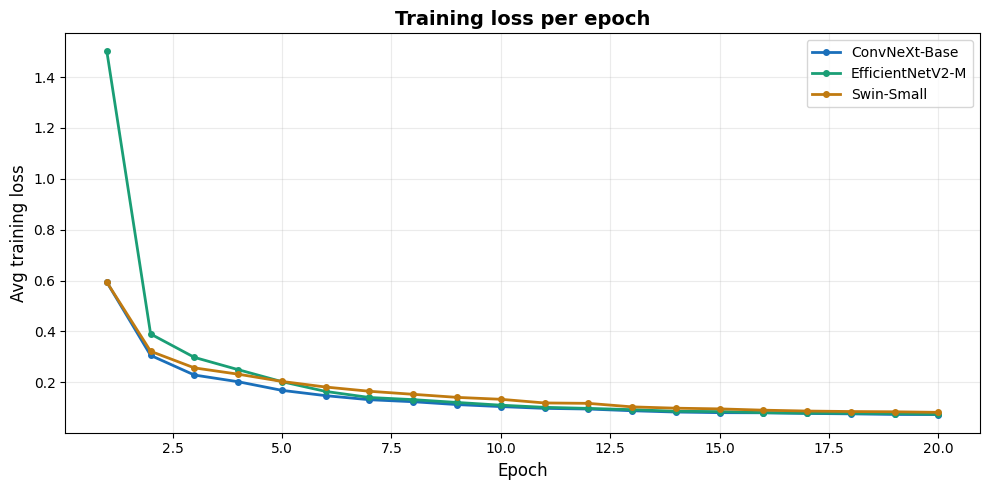

Saved → plot_train_loss.png


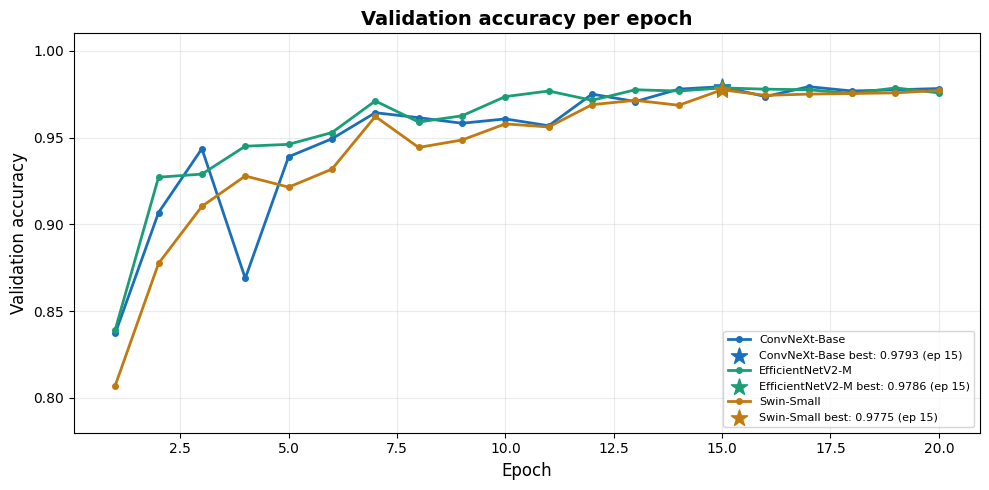

Saved → plot_val_accuracy.png


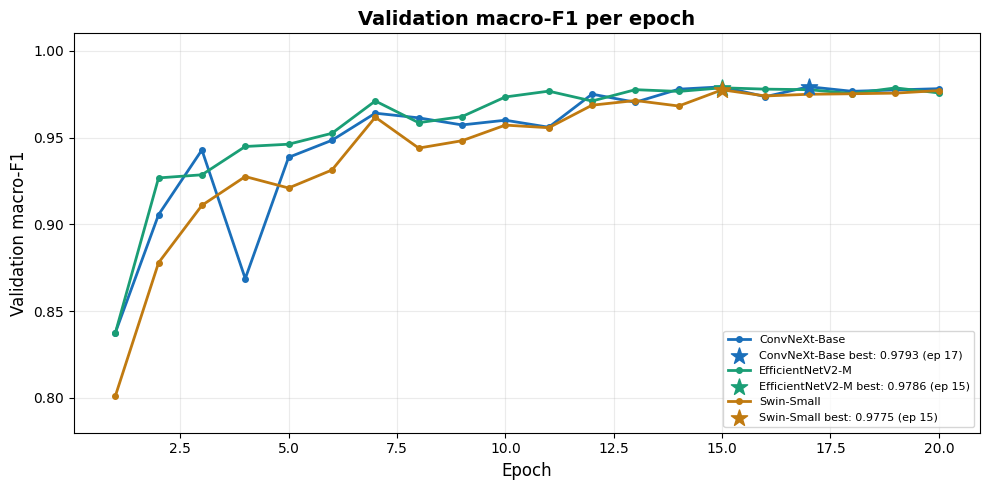

Saved → plot_val_f1.png

Running test inference for confusion matrix...


Inference: 100%|██████████| 44/44 [01:09<00:00,  1.58s/it]


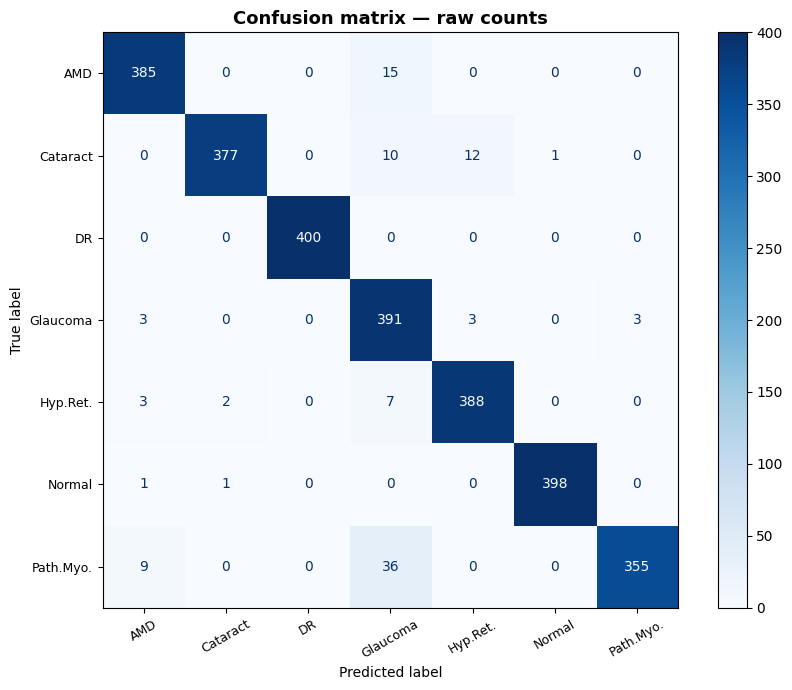

Saved → plot_confusion_matrix_counts.png


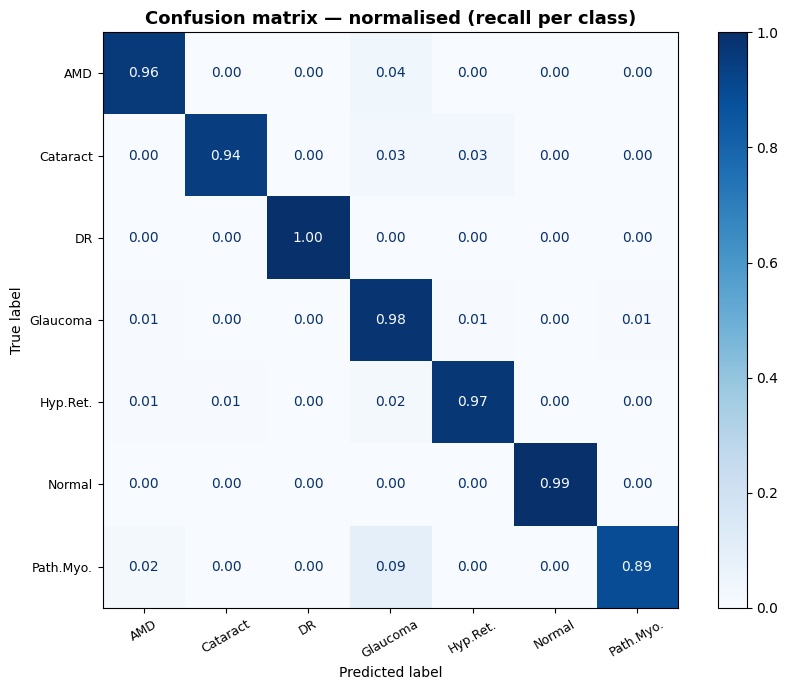

Saved → plot_confusion_matrix_normalised.png

Classification Report:
                 precision    recall  f1-score   support

            AMD       0.96      0.96      0.96       400
       Cataract       0.99      0.94      0.97       400
             DR       1.00      1.00      1.00       400
       Glaucoma       0.85      0.98      0.91       400
Hyp.Retinopathy       0.96      0.97      0.97       400
  Normal_Fundus       1.00      0.99      1.00       400
    Path.Myopia       0.99      0.89      0.94       400

       accuracy                           0.96      2800
      macro avg       0.97      0.96      0.96      2800
   weighted avg       0.97      0.96      0.96      2800

Saved → classification_report.txt

ALL OUTPUT FILES
  convnext_best.pth                               350.4 MB
  efficientv2_best.pth                            213.0 MB
  ensemble_weights.json                             0.0 MB
  swin_best.pth                                   195.5 MB
  plot_train_

In [19]:
# ============================================================
# CELL 16 — Plots + reports + save verification
# ============================================================
import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

# ---- Save ensemble weights ----
with open(f"{SAVE_DIR}/ensemble_weights.json", "w") as f:
    json.dump({
        "convnext":    float(optimal_w[0]),
        "efficientv2": float(optimal_w[1]),
        "swin":        float(optimal_w[2])
    }, f, indent=2)

colors = {
    "convnext":    "#1a6fba",
    "efficientv2": "#1a9e75",
    "swin":        "#c07a10",
}
names = {
    "convnext":    "ConvNeXt-Base",
    "efficientv2": "EfficientNetV2-M",
    "swin":        "Swin-Small",
}

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{filename}",
                dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved → {filename}")


# ---- Plot 1: Training Loss ----
fig, ax = plt.subplots(figsize=(10, 5))
for key, c in colors.items():
    ep = range(1, len(history[key]["train_loss"]) + 1)
    ax.plot(ep, history[key]["train_loss"], color=c, linewidth=2,
            marker="o", markersize=4, label=names[key])
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Avg training loss", fontsize=12)
ax.set_title("Training loss per epoch", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
save_plot("plot_train_loss.png")


# ---- Plot 2: Validation Accuracy ----
fig, ax = plt.subplots(figsize=(10, 5))
for key, c in colors.items():
    ep     = range(1, len(history[key]["val_acc"]) + 1)
    vals   = history[key]["val_acc"]
    best_e = int(np.argmax(vals)) + 1
    best_v = max(vals)
    ax.plot(ep, vals, color=c, linewidth=2,
            marker="o", markersize=4, label=names[key])
    ax.scatter([best_e], [best_v], color=c, s=150, zorder=5, marker="*",
               label=f"{names[key]} best: {best_v:.4f} (ep {best_e})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation accuracy", fontsize=12)
ax.set_title("Validation accuracy per epoch", fontsize=14, fontweight="bold")
ax.set_ylim(0.78, 1.01)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.25)
save_plot("plot_val_accuracy.png")


# ---- Plot 3: Validation F1 ----
fig, ax = plt.subplots(figsize=(10, 5))
for key, c in colors.items():
    ep     = range(1, len(history[key]["val_f1"]) + 1)
    vals   = history[key]["val_f1"]
    best_e = int(np.argmax(vals)) + 1
    best_v = max(vals)
    ax.plot(ep, vals, color=c, linewidth=2,
            marker="o", markersize=4, label=names[key])
    ax.scatter([best_e], [best_v], color=c, s=150, zorder=5, marker="*",
               label=f"{names[key]} best: {best_v:.4f} (ep {best_e})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation macro-F1", fontsize=12)
ax.set_title("Validation macro-F1 per epoch", fontsize=14, fontweight="bold")
ax.set_ylim(0.78, 1.01)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.25)
save_plot("plot_val_f1.png")


# ---- Confusion matrix inference ----
print("\nRunning test inference for confusion matrix...")
all_preds, all_true = [], []
convnext.eval(); efficientv2.eval(); swin.eval()

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference"):
        images = images.to(device)
        p1 = torch.softmax(convnext(images),    dim=1).cpu().numpy()
        p2 = torch.softmax(efficientv2(images), dim=1).cpu().numpy()
        p3 = torch.softmax(swin(images),        dim=1).cpu().numpy()
        avg = optimal_w[0]*p1 + optimal_w[1]*p2 + optimal_w[2]*p3
        all_preds.extend(avg.argmax(axis=1).tolist())
        all_true.extend(labels.numpy().tolist())

short = ["AMD", "Cataract", "DR", "Glaucoma",
         "Hyp.Ret.", "Normal", "Path.Myo."]
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


# ---- Plot 4: Confusion Matrix raw counts ----
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=short).plot(
    ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion matrix — raw counts",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
save_plot("plot_confusion_matrix_counts.png")


# ---- Plot 5: Confusion Matrix normalised ----
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_norm, display_labels=short).plot(
    ax=ax, colorbar=True, cmap="Blues", values_format=".2f")
ax.set_title("Confusion matrix — normalised (recall per class)",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
save_plot("plot_confusion_matrix_normalised.png")


# ---- Classification report ----
report = classification_report(
    all_true, all_preds,
    target_names=["AMD", "Cataract", "DR", "Glaucoma",
                  "Hyp.Retinopathy", "Normal_Fundus", "Path.Myopia"]
)
print("\nClassification Report:")
print(report)
with open("/kaggle/working/classification_report.txt", "w") as f:
    f.write(report)
print("Saved → classification_report.txt")


# ---- Final file list ----
print("\n" + "="*50)
print("ALL OUTPUT FILES")
print("="*50)
for f in sorted(os.listdir(SAVE_DIR)):
    mb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"  {f:45s} {mb:7.1f} MB")
for f in ["plot_train_loss.png", "plot_val_accuracy.png",
          "plot_val_f1.png", "plot_confusion_matrix_counts.png",
          "plot_confusion_matrix_normalised.png",
          "classification_report.txt"]:
    path = f"/kaggle/working/{f}"
    mb   = os.path.getsize(path) / 1e6
    print(f"  {f:45s} {mb:7.1f} MB")

print("\n*** IMPORTANT: Click Save Version → Save & Run All ***")
print("This permanently commits all files above.")